# Week 6 Assessment - Image Denoising with Autoencoders

**Author:** Anvesh Annepaga  
**Project:** MNIST Digit Denoising using Convolutional Autoencoders

In this notebook, we build and train a Convolutional Autoencoder (CAE) to remove Gaussian noise from handwritten digits in the MNIST dataset.

## 1. Setup and Imports
Let's install the required packages, import our libraries, and set a random seed so our training is reproducible.

In [12]:
!pip install -q torchsummary scikit-image torchvision


[notice] A new release of pip available: 22.3.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [13]:
import os
import random
import warnings
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torchvision import datasets
from torchsummary import summary
from skimage.metrics import peak_signal_noise_ratio, structural_similarity

warnings.filterwarnings('ignore')

# Set seed for reproducibility
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

Using device: cpu


## 2. Loading and Preprocessing Data
We load the MNIST dataset directly via PyTorch's torchvision library. We'll split the 60,000 training images into an 80/20 train-validation split and normalize pixel intensity values to [0, 1].

In [14]:
# Download and load MNIST dataset natively using PyTorch
train_ds = datasets.MNIST(root='./data', train=True, download=True)
test_ds = datasets.MNIST(root='./data', train=False, download=True)

# Extract numpy arrays
x_train_full = train_ds.data.numpy()
y_train_full = train_ds.targets.numpy()
x_test_data = test_ds.data.numpy()
y_test_data = test_ds.targets.numpy()

# 80/20 train-val split
x_train_data, x_val_data, y_train_data, y_val_data = train_test_split(
    x_train_full, y_train_full, test_size=0.2, random_state=seed, stratify=y_train_full
)

# Convert to float32 and scale to [0, 1]
x_train_data = x_train_data.astype('float32') / 255.0
x_val_data = x_val_data.astype('float32') / 255.0
x_test_data = x_test_data.astype('float32') / 255.0

print('Train shape:', x_train_data.shape)
print('Val shape:', x_val_data.shape)
print('Test shape:', x_test_data.shape)

Train shape: (48000, 28, 28)
Val shape: (12000, 28, 28)
Test shape: (10000, 28, 28)


## 3. Adding Gaussian Noise
To train our denoising model, we need noisy images. We add random normal noise (mean=0, std=1) scaled by 0.45 to the clean images, then clip the values to stay within [0, 1].

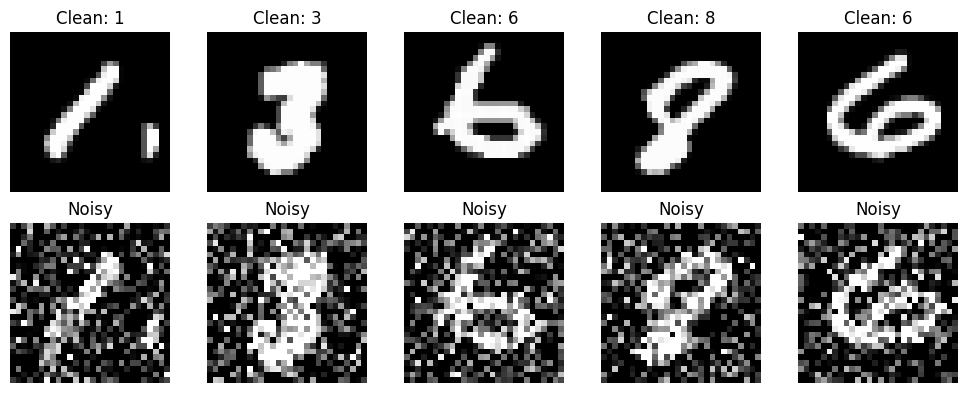

In [15]:
def apply_gaussian_noise(imgs, noise_factor=0.45):
    noise = np.random.normal(0.0, 1.0, imgs.shape)
    noisy = imgs + noise_factor * noise
    return np.clip(noisy, 0.0, 1.0)

# Generate noisy datasets
train_noisy = apply_gaussian_noise(x_train_data)
val_noisy = apply_gaussian_noise(x_val_data)
test_noisy = apply_gaussian_noise(x_test_data)

# Visualize clean vs noisy comparison
plt.figure(figsize=(10, 4))
for i in range(5):
    # Clean
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train_data[i], cmap='gray')
    plt.title(f'Clean: {y_train_data[i]}')
    plt.axis('off')
    # Noisy
    plt.subplot(2, 5, i + 6)
    plt.imshow(train_noisy[i], cmap='gray')
    plt.title('Noisy')
    plt.axis('off')
plt.tight_layout()
plt.show()

## 4. Dataset and DataLoaders
We wrap our noisy and clean image pairs in a PyTorch Dataset and create DataLoaders with batch size 256.

In [16]:
class DenoisingDataset(Dataset):
    def __init__(self, noisy_imgs, clean_imgs):
        self.noisy = noisy_imgs
        self.clean = clean_imgs
        
    def __len__(self):
        return len(self.clean)
        
    def __getitem__(self, idx):
        # Add channel dimension -> (1, 28, 28)
        noisy_tensor = torch.tensor(self.noisy[idx], dtype=torch.float32).unsqueeze(0)
        clean_tensor = torch.tensor(self.clean[idx], dtype=torch.float32).unsqueeze(0)
        return noisy_tensor, clean_tensor

batch_size = 256

train_loader = DataLoader(DenoisingDataset(train_noisy, x_train_data), batch_size=batch_size, shuffle=True)
val_loader = DataLoader(DenoisingDataset(val_noisy, x_val_data), batch_size=batch_size, shuffle=False)
test_loader = DataLoader(DenoisingDataset(test_noisy, x_test_data), batch_size=batch_size, shuffle=False)

print('Total train batches:', len(train_loader))

Total train batches: 188


## 5. Autoencoder Architecture
We design a Convolutional Autoencoder using LeakyReLU activations and Batch Normalization. 
- **Encoder:** Downsamples the 28x28 image to a 7x7x64 feature bottleneck.
- **Decoder:** Upsamples back to 28x28 using ConvTranspose2d, ending with a Sigmoid activation.

In [17]:
class ConvAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        
        # Encoder (28x28 -> 14x14 -> 7x7)
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(16),
            nn.LeakyReLU(0.1, inplace=True),
            
            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.LeakyReLU(0.1, inplace=True),
            
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.1, inplace=True)
        )
        
        # Decoder (7x7 -> 14x14 -> 28x28)
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(32),
            nn.LeakyReLU(0.1, inplace=True),
            
            nn.ConvTranspose2d(32, 16, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(16),
            nn.LeakyReLU(0.1, inplace=True),
            
            nn.Conv2d(16, 1, kernel_size=3, stride=1, padding=1),
            nn.Sigmoid()
        )
        
    def forward(self, x):
        return self.decoder(self.encoder(x))

model = ConvAutoencoder().to(device)
summary(model, (1, 28, 28))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 16, 28, 28]             160
       BatchNorm2d-2           [-1, 16, 28, 28]              32
         LeakyReLU-3           [-1, 16, 28, 28]               0
            Conv2d-4           [-1, 32, 14, 14]           4,640
       BatchNorm2d-5           [-1, 32, 14, 14]              64
         LeakyReLU-6           [-1, 32, 14, 14]               0
            Conv2d-7             [-1, 64, 7, 7]          18,496
       BatchNorm2d-8             [-1, 64, 7, 7]             128
         LeakyReLU-9             [-1, 64, 7, 7]               0
  ConvTranspose2d-10           [-1, 32, 14, 14]          18,464
      BatchNorm2d-11           [-1, 32, 14, 14]              64
        LeakyReLU-12           [-1, 32, 14, 14]               0
  ConvTranspose2d-13           [-1, 16, 28, 28]           4,624
      BatchNorm2d-14           [-1, 16,

## 6. Training Loop
We train the model for 25 epochs using MSE loss and the AdamW optimizer. A scheduler halves the learning rate if validation loss stops improving, and we save the best model checkpoint.

In [18]:
epochs = 25
lr = 0.002
model_file = 'best_denoising_model.pth'

criterion = nn.MSELoss()
optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

train_losses, val_losses = [], []
best_loss = float('inf')

print('Training started...')
for epoch in range(1, epochs + 1):
    # Train
    model.train()
    train_loss = 0.0
    for noisy, clean in train_loader:
        noisy, clean = noisy.to(device), clean.to(device)
        
        optimizer.zero_grad()
        output = model(noisy)
        loss = criterion(output, clean)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item() * noisy.size(0)
        
    train_loss /= len(train_loader.dataset)
    train_losses.append(train_loss)
    
    # Validation
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for noisy, clean in val_loader:
            noisy, clean = noisy.to(device), clean.to(device)
            output = model(noisy)
            loss = criterion(output, clean)
            val_loss += loss.item() * noisy.size(0)
            
    val_loss /= len(val_loader.dataset)
    val_losses.append(val_loss)
    
    scheduler.step(val_loss)
    
    print(f'Epoch {epoch:02d}/{epochs} - Train Loss: {train_loss:.6f} - Val Loss: {val_loss:.6f}')
    
    # Save best model
    if val_loss < best_loss:
        best_loss = val_loss
        torch.save(model.state_dict(), model_file)
        print(' --> Saved new best checkpoint!')

Training started...
Epoch 01/25 - Train Loss: 0.021324 - Val Loss: 0.010322
 --> Saved new best checkpoint!
Epoch 02/25 - Train Loss: 0.009831 - Val Loss: 0.009471
 --> Saved new best checkpoint!
Epoch 03/25 - Train Loss: 0.009308 - Val Loss: 0.009139
 --> Saved new best checkpoint!
Epoch 04/25 - Train Loss: 0.009062 - Val Loss: 0.008986
 --> Saved new best checkpoint!
Epoch 05/25 - Train Loss: 0.008889 - Val Loss: 0.008929
 --> Saved new best checkpoint!
Epoch 06/25 - Train Loss: 0.008798 - Val Loss: 0.008820
 --> Saved new best checkpoint!
Epoch 07/25 - Train Loss: 0.008711 - Val Loss: 0.008680
 --> Saved new best checkpoint!
Epoch 08/25 - Train Loss: 0.008628 - Val Loss: 0.008665
 --> Saved new best checkpoint!
Epoch 09/25 - Train Loss: 0.008557 - Val Loss: 0.008616
 --> Saved new best checkpoint!
Epoch 10/25 - Train Loss: 0.008507 - Val Loss: 0.008577
 --> Saved new best checkpoint!
Epoch 11/25 - Train Loss: 0.008461 - Val Loss: 0.008579
Epoch 12/25 - Train Loss: 0.008434 - Val Los

## 7. Evaluation & Results
Let's load our best saved model, plot the loss curves, and calculate the PSNR and SSIM quality metrics on the test set.

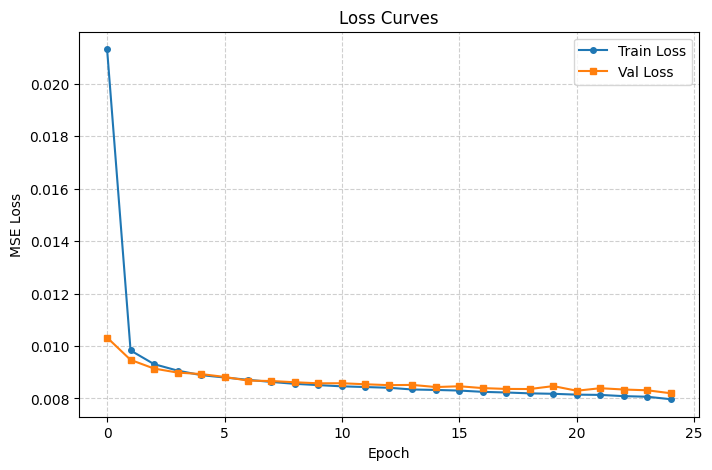

In [19]:
# Load best checkpoint
model.load_state_dict(torch.load(model_file, map_location=device))
model.eval()

# Plot learning curves
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label='Train Loss', marker='o', markersize=4)
plt.plot(val_losses, label='Val Loss', marker='s', markersize=4)
plt.title('Loss Curves')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [20]:
# Calculate PSNR and SSIM on test dataset
total_psnr = 0.0
total_ssim = 0.0
count = 0

with torch.no_grad():
    for noisy, clean in test_loader:
        noisy_dev = noisy.to(device)
        output = model(noisy_dev).cpu().numpy().squeeze()
        clean_np = clean.numpy().squeeze()
        
        for i in range(output.shape[0]):
            total_psnr += peak_signal_noise_ratio(clean_np[i], output[i], data_range=1.0)
            total_ssim += structural_similarity(clean_np[i], output[i], data_range=1.0)
            count += 1

print(f'Test PSNR: {total_psnr / count:.2f} dB')
print(f'Test SSIM: {total_ssim / count:.4f}')

Test PSNR: 21.24 dB
Test SSIM: 0.8852


Finally, let's visualize some denoised test images side by side with the noisy inputs and original ground truth.

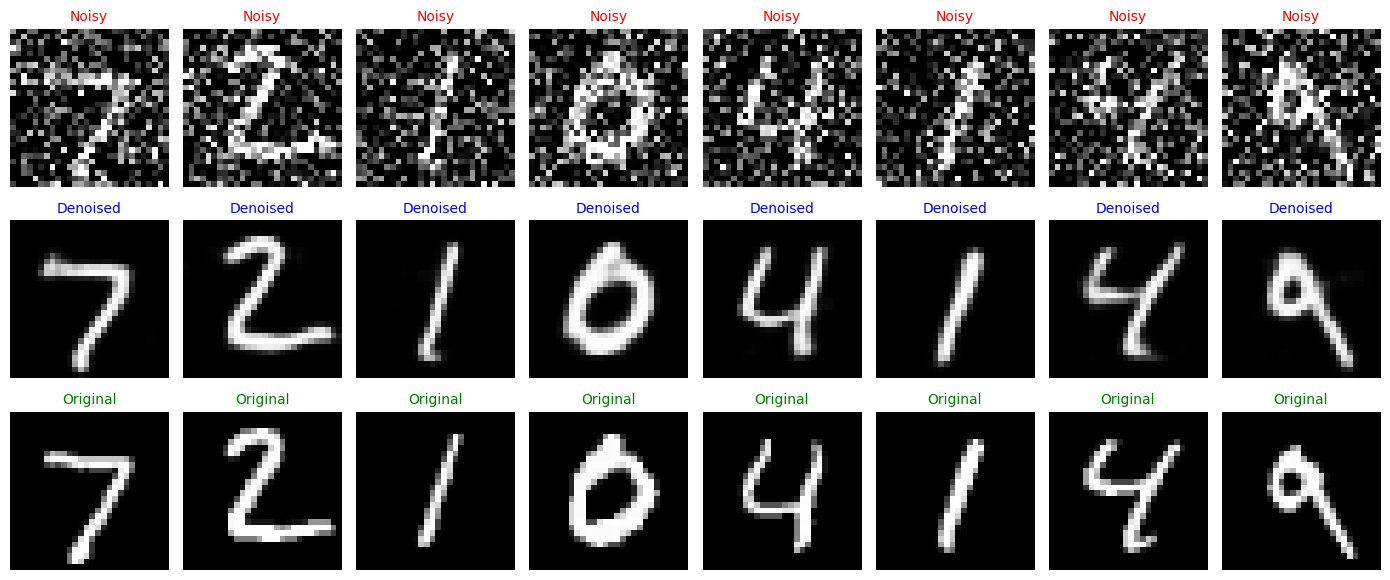

In [21]:
# Visualize test predictions
noisy_batch, clean_batch = next(iter(test_loader))
with torch.no_grad():
    preds = model(noisy_batch.to(device)).cpu()

n = 8
plt.figure(figsize=(14, 6))
for i in range(n):
    # Noisy input
    plt.subplot(3, n, i + 1)
    plt.imshow(noisy_batch[i].squeeze(), cmap='gray')
    plt.title('Noisy', color='red', fontsize=10)
    plt.axis('off')
    
    # Denoised prediction
    plt.subplot(3, n, n + i + 1)
    plt.imshow(preds[i].squeeze(), cmap='gray')
    plt.title('Denoised', color='blue', fontsize=10)
    plt.axis('off')
    
    # Clean ground truth
    plt.subplot(3, n, 2 * n + i + 1)
    plt.imshow(clean_batch[i].squeeze(), cmap='gray')
    plt.title('Original', color='green', fontsize=10)
    plt.axis('off')

plt.tight_layout()
plt.show()